Importando as bibliotecas iniciais

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
nasa_machine = pd.read_csv('battery_dataset/metadata.csv')

In [47]:
nasa_machine 

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


Verificando se existem dados faltantes 

In [48]:
nasa_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 7565 non-null   str  
 1   start_time           7565 non-null   str  
 2   ambient_temperature  7565 non-null   int64
 3   battery_id           7565 non-null   str  
 4   test_id              7565 non-null   int64
 5   uid                  7565 non-null   int64
 6   filename             7565 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   1956 non-null   str  
 9   Rct                  1956 non-null   str  
dtypes: int64(3), str(7)
memory usage: 591.1 KB


In [49]:
nasa_machine.isnull().sum()

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64

In [50]:
nasa_machine['type'].value_counts()

type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64

 ### Descobrindo o número de baterias que existem no banco de dados

In [51]:
nasa_machine["battery_id"].nunique()

34

### Descrição das baterias

In [52]:
nasa_machine.groupby("battery_id").size().describe()

count     34.000000
mean     222.500000
std      172.979461
min       62.000000
25%       97.000000
50%      173.500000
75%      275.000000
max      616.000000
dtype: float64

Filtrar o DataFrame para trabalhar com a capacidade

In [53]:
df_descarga = nasa_machine[nasa_machine['type'] == 'discharge'].copy()

df_descarga.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


Criacao de Coluna

In [54]:
# Contagem inicial sequencial de descargas por bateria, para identificar o ciclo de cada bateria
df_descarga['ciclo'] = df_descarga.groupby('battery_id').cumcount() + 1

#Exibem apenas as colunas de interesse, para facilitar a visualização
df_descarga[['battery_id', 'ciclo', 'ambient_temperature', 'Capacity']].head(10)

,battery_id,ciclo,ambient_temperature,Capacity
0,B0047,1,4,1.6743047446975208
4,B0047,2,4,1.5243662105099023
6,B0047,3,4,1.5080762969973425
8,B0047,4,4,1.4835577960067696
10,B0047,5,4,1.4671391666146525
12,B0047,6,4,1.448858156982267
16,B0047,7,4,1.4458534180949325
20,B0047,8,4,1.431118266178283
22,B0047,9,4,1.4192745516578533
24,B0047,10,4,1.3999974221808271


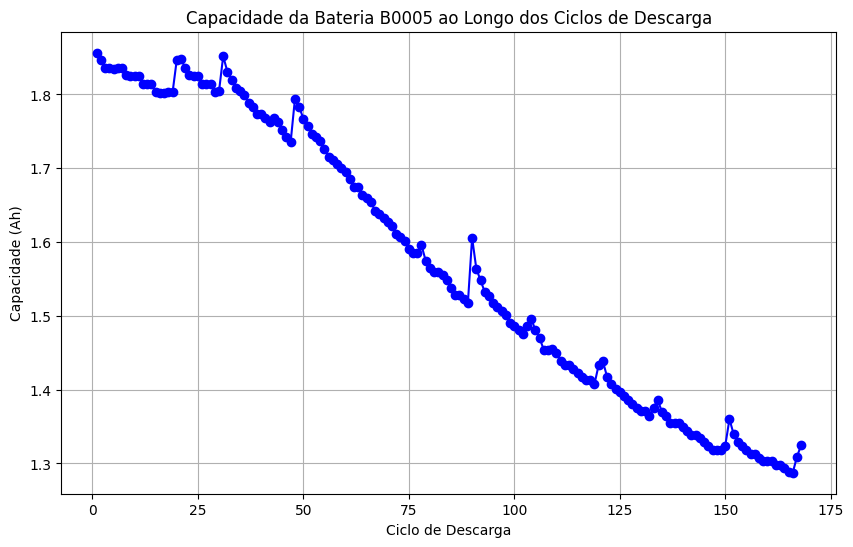

In [55]:
# Convertendo de string para float, para evitar problemas de plotagem
df_descarga['Capacity'] = pd.to_numeric(df_descarga['Capacity'], errors='coerce')
df_descarga['ambient_temperature'] = pd.to_numeric(df_descarga['ambient_temperature'], errors='coerce')
df_descarga = df_descarga.dropna(subset=['Capacity', 'ambient_temperature']).copy()


battery_exemplo = df_descarga[df_descarga['battery_id'] == 'B0005']

plt.figure(figsize=(10, 6))
plt.plot(battery_exemplo['ciclo'], battery_exemplo['Capacity'], marker='o', linestyle='-', color='b')
plt.xlabel('Ciclo de Descarga')
plt.ylabel('Capacidade (Ah)')
plt.title('Capacidade da Bateria B0005 ao Longo dos Ciclos de Descarga')
plt.grid(True)
plt.show()


Definindo as variáveis (X) e (Y)

In [56]:
X = df_descarga[['ciclo', 'ambient_temperature']].copy()
y = df_descarga['Capacity']

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2769, 2)
Formato de y: (2769,)



Treino e Teste

In [57]:
from sklearn.model_selection import GroupShuffleSplit

In [58]:
#Instancia o divisor baseado em grupos
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

#Deixa como agrupador a coluna 'battery_id' para garantir que baterias inteiras sejam mantidas juntas nos conjuntos de treino e teste
train_idx, test_idx = next(gss.split(X, y, groups=df_descarga['battery_id']))

#Cria os conjuntos de treino e teste respeitando os grupos
x_treino = X.iloc[train_idx]
y_treino = y.iloc[train_idx]
x_teste = X.iloc[test_idx]
y_teste = y.iloc[test_idx]

#Verificação das baterias presentes em cada conjunto
baterias_treino = df_descarga.iloc[train_idx]['battery_id'].unique()
baterias_teste = df_descarga.iloc[test_idx]['battery_id'].unique()

print(f"Baterias de Treino ({len(baterias_treino)}):", baterias_treino)
print(f"Baterias de Teste ({len(baterias_teste)}):", baterias_teste)

Baterias de Treino (27): <StringArray>
['B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040', 'B0028',
 'B0034', 'B0033', 'B0030', 'B0041', 'B0027', 'B0036', 'B0025', 'B0026',
 'B0031', 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053',
 'B0054', 'B0056', 'B0055']
Length: 27, dtype: str
Baterias de Teste (7): <StringArray>
['B0047', 'B0029', 'B0042', 'B0038', 'B0044', 'B0049', 'B0050']
Length: 7, dtype: str


Modelo RandomForestRegressor

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [60]:
#Criando o modelo
rf_nasa = RandomForestRegressor(n_estimators=100, random_state=42)
#Treinando o modelo com os dados de treino
rf_nasa.fit(x_treino, y_treino)

previsoes = rf_nasa.predict(x_teste)

In [61]:
rf_mse = mean_squared_error(y_teste, previsoes)

rf_rmse = np.sqrt(rf_mse)


In [62]:
rf_mae = mean_absolute_error(y_teste, previsoes)
rf_r2 = r2_score(y_teste, previsoes)

print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"R²:   {rf_r2:.4f}")

RMSE: 0.4460
MAE:  0.3264
R²:   0.5191


In [63]:
print(f"O erro médio (RMSE) do modelo é: {rf_rmse:.4f} Ah")

O erro médio (RMSE) do modelo é: 0.4460 Ah


In [64]:
# 2. Avaliação rápida no conjunto de TESTE
preds_rf_teste = rf_nasa.predict(x_teste)
rf_rmse_teste = np.sqrt(mean_squared_error(y_teste, preds_rf_teste))
rf_mae_teste = mean_absolute_error(y_teste, preds_rf_teste)
rf_r2_teste = r2_score(y_teste, preds_rf_teste)

print("--- Desempenho do Random Forest no TESTE ---")
print(f"RMSE: {rf_rmse_teste:.4f}")
print(f"MAE:  {rf_mae_teste:.4f}")
print(f"R²:   {rf_r2_teste:.4f}")
print("-" * 45)

--- Desempenho do Random Forest no TESTE ---
RMSE: 0.4460
MAE:  0.3264
R²:   0.5191
---------------------------------------------


Modelo - LinearRegression

In [65]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-0. , 0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['ciclo','ambient_temperature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9549
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [66]:
alguns_dados = x_treino.iloc[:5]
algumas_labels = y_treino.iloc[:5]

print("Predicoes", lin_reg.predict(alguns_dados))
print("Labels", algumas_labels.values)

Predicoes [1.05144347 1.05057633 1.04970919 1.04884205 1.04797491]
Labels [1.08197939 0.9279524  0.88519361 0.85810107 0.84093522]


In [67]:
from sklearn.metrics import mean_squared_error

preds = lin_reg.predict(x_treino)
lin_mse = mean_squared_error(y_treino, preds)

lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.31483867490020023)

In [68]:
# Fazendo as previsões nos dados de TESTE
previsoes_teste = lin_reg.predict(x_teste)

# Calculando as métricas de avaliação
mse_teste = mean_squared_error(y_teste, previsoes_teste)
rmse_teste = np.sqrt(mse_teste)
mae_teste = mean_absolute_error(y_teste, previsoes_teste)
r2_teste = r2_score(y_teste, previsoes_teste)

# Exibindo os resultados
print(f" Desempenho do LinearRegression ")
print(f"RMSE (Erro Quadrático Médio): {rmse_teste:.4f}")
print(f"MAE (Erro Absoluto Médio):    {mae_teste:.4f}")
print(f"R² (Coef. Determinação):    {r2_teste:.4f}")

 Desempenho do LinearRegression 
RMSE (Erro Quadrático Médio): 0.5390
MAE (Erro Absoluto Médio):    0.4301
R² (Coef. Determinação):    0.2977


In [69]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(x_treino, y_treino)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [70]:
preds = tree_reg.predict(x_treino)
tree_mse = mean_squared_error(y_treino, preds)

tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.2707979465873724)

In [71]:
# 1. Previsão nos dados de TESTE
preds_tree_teste = tree_reg.predict(x_teste)

# 2. Métricas no TESTE
tree_rmse_teste = np.sqrt(mean_squared_error(y_teste, preds_tree_teste))
tree_mae_teste = mean_absolute_error(y_teste, preds_tree_teste)
tree_r2_teste = r2_score(y_teste, preds_tree_teste)

print("--- Desempenho da Decision Tree no TESTE ---")
print(f"RMSE: {tree_rmse_teste:.4f}")
print(f"MAE:  {tree_mae_teste:.4f}")
print(f"R²:   {tree_r2_teste:.4f}")

--- Desempenho da Decision Tree no TESTE ---
RMSE: 0.4431
MAE:  0.3209
R²:   0.5253


Cross Val 

In [79]:
from sklearn.model_selection import GroupKFold, cross_val_score

# Usa GroupKFold para não vazar dados entre as dobras (folds)
gkf = GroupKFold(n_splits=5) # 5 ou 10 folds dependendo da quantidade de baterias

scores_rf = cross_val_score(
    rf_nasa, 
    x_treino, 
    y_treino, 
    scoring="neg_mean_squared_error", 
    cv=gkf,
    groups=df_descarga.iloc[train_idx]['battery_id'] # Importante passar os grupos aqui!
)

rmse_scores_rf = np.sqrt(-scores_rf)
print("Média do RMSE(RF) (GroupKFold):", round(rmse_scores_rf.mean(), 4))

Média do RMSE(RF) (GroupKFold): 0.3234


In [80]:
gkf = GroupKFold(n_splits=5) 

scores_tree = cross_val_score(
    tree_reg, 
    x_treino, 
    y_treino, 
    scoring="neg_mean_squared_error", 
    cv=gkf,
    groups=df_descarga.iloc[train_idx]['battery_id'] 
)

rmse_scores_tree = np.sqrt(-scores_tree)
print("Média do RMSE(Tree) (GroupKFold):", round(rmse_scores_tree.mean(), 4))

Média do RMSE(Tree) (GroupKFold): 0.3262
